# Empirical Replication: *The Price Impact of Order Book Events*
**Authors:** Rama Cont, Arseniy Kukanov, and Sasha Stoikov (2014)  
**Pipeline Focus:** End-to-End High-Frequency Order Book Analysis across Crypto Perpetuals & U.S. Equities

---

## Academic Framework
This notebook replicates and extends the empirical methodology of Cont et al. (2014). It evaluates how **Order Flow Imbalance (OFI)** drives short-term price impact at the microsecond/millisecond top-of-book level.

### Core Theoretical Formulations
1. **Event-Level Order Flow Imbalance ($e_n$):**
   $$e_n = I(P_{n}^{\text{bid}} \ge P_{n-1}^{\text{bid}}) q_n^{\text{bid}} - I(P_n^{\text{bid}} \le P_{n-1}^{\text{bid}}) q_{n-1}^{\text{bid}} - I(P_n^{\text{ask}} \le P_{n-1}^{\text{ask}}) q_n^{\text{ask}} + I(P_n^{\text{ask}} \ge P_{n-1}^{\text{ask}}) q_{n-1}^{\text{ask}}$$

2. **Linear Price Impact Model:**
   $$\Delta P_k = \alpha + \beta \cdot \text{OFI}_k + \epsilon_k$$

3. **Price Impact Scaling with Market Depth ($D_k$):**
   $$\log(\beta) = C - \lambda \log(\bar{D}_k) + \epsilon$$

4. **Volume Exponent Modeling ($H$):**
   $$\log(|\Delta P_k|) = C + H \cdot \log(V_k) + \epsilon$$

---


## Section 1: Project Environment & Global Configurations
In this section, we define paths, asset lists (Crypto tokens and stock tickers), timezone specifications, and default sampling parameters ($10\text{s}$ aggregation, $30\text{min}$ regression windows).

In [6]:
from pathlib import Path

# =================================================
# Crypto Environment Configuration
# =================================================
PROJECT_ROOT = Path(".").resolve()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
RAW_TRADES_DIR = PROJECT_ROOT / "data" / "raw_trades"

TOKENS = ["BTC", "ETH", "SOL", "HYPE", "DOGE"]
SAMPLE_DATES = ["2026-05-01", "2026-06-01", "2026-07-01"]

COLUMN_NAMES = {
    "timestamp": "timestamp",
    "bid_price": "bid_price",
    "bid_size": "bid_amount",
    "ask_price": "ask_price",
    "ask_size": "ask_amount",
}

TRADE_COLUMN_NAMES = {
    "timestamp": "timestamp",
    "trade_id": "id",
    "side": "side",
    "price": "price",
    "amount": "amount",
}

TIMESTAMP_UNIT = "us"
AGGREGATION_FREQUENCY = "10s"
REGRESSION_FREQUENCY = "30min"
MAX_GAP_SECONDS = 15
MIN_REGRESSION_OBSERVATIONS = 120
HAC_MAX_LAGS = 3

def create_folders():
    PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    for token in TOKENS:
        (RAW_DATA_DIR / token).mkdir(parents=True, exist_ok=True)
        (RAW_TRADES_DIR / token).mkdir(parents=True, exist_ok=True)
        (PROCESSED_DATA_DIR / token).mkdir(parents=True, exist_ok=True)
        (RESULTS_DIR / token).mkdir(parents=True, exist_ok=True)

# =================================================
# Stock Market Configuration
# =================================================
STOCK_RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw_stocks"
STOCK_RAW_FILE = STOCK_RAW_DATA_DIR / "filtered_nbbo_data.csv"
STOCK_PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed_stocks"
STOCK_RESULTS_DIR = PROJECT_ROOT / "results" / "stocks"

STOCK_SYMBOLS = ["AAPL", "AMZN"]
STOCK_COLUMN_NAMES = {
    "exchange": "exchange",
    "symbol": "symbol",
    "timestamp": "timestamp",
    "local_timestamp": "local_timestamp",
    "ask_size": "ask_amount",
    "ask_price": "ask_price",
    "bid_size": "bid_amount",
    "bid_price": "bid_price",
}

ACTUAL_SESSION_DATE = None
SYNTHETIC_DATE = "2000-01-03"
BASE_DATE = SYNTHETIC_DATE if ACTUAL_SESSION_DATE is None else ACTUAL_SESSION_DATE
SESSION_ID = "undated_stock_session" if ACTUAL_SESSION_DATE is None else ACTUAL_SESSION_DATE
MARKET_TIMEZONE = "America/New_York"

MARKET_OPEN_HOUR, MARKET_OPEN_MINUTE = 9, 30
MARKET_CLOSE_HOUR, MARKET_CLOSE_MINUTE = 16, 0

def create_stock_folders():
    STOCK_RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
    STOCK_PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
    STOCK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    for symbol in STOCK_SYMBOLS:
        (STOCK_PROCESSED_DATA_DIR / symbol).mkdir(parents=True, exist_ok=True)
        (STOCK_RESULTS_DIR / symbol).mkdir(parents=True, exist_ok=True)

create_folders()
create_stock_folders()
print("Directories created successfully.")

Directories created successfully.


## Section 2: High-Frequency Data Cleaning & Event-OFI Processing
This section implements top-of-book filtering, tick size estimation, event-level OFI vector derivation, and discrete 10-second aggregations for both perpetual futures and equity NBBO streams.

In [7]:
import numpy as np
import pandas as pd

def read_quote_file(file_path, token):
    raw = pd.read_csv(file_path, compression="infer")
    required = [COLUMN_NAMES[k] for k in ["timestamp", "bid_price", "bid_size", "ask_price", "ask_size"]]
    data = raw[required].copy().rename(columns={
        COLUMN_NAMES["timestamp"]: "timestamp_utc",
        COLUMN_NAMES["bid_price"]: "best_bid_price",
        COLUMN_NAMES["bid_size"]: "best_bid_size",
        COLUMN_NAMES["ask_price"]: "best_ask_price",
        COLUMN_NAMES["ask_size"]: "best_ask_size",
    })
    data["timestamp_utc"] = pd.to_datetime(data["timestamp_utc"], unit=TIMESTAMP_UNIT, utc=True, errors="coerce")
    for col in ["best_bid_price", "best_bid_size", "best_ask_price", "best_ask_size"]:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    valid = (data["timestamp_utc"].notna()) & (data["best_bid_price"] > 0) & (data["best_ask_price"] > 0) \
            & (data["best_bid_size"] > 0) & (data["best_ask_size"] > 0) & (data["best_bid_price"] < data["best_ask_price"])
    data = data.loc[valid].sort_values("timestamp_utc").drop_duplicates()
    main_date = data["timestamp_utc"].dt.strftime("%Y-%m-%d").mode().iloc[0]
    data = data.loc[data["timestamp_utc"].dt.strftime("%Y-%m-%d") == main_date].copy()
    data["token"], data["source_date"] = token, main_date
    data["mid_price"] = (data["best_bid_price"] + data["best_ask_price"]) / 2
    data["spread"] = data["best_ask_price"] - data["best_bid_price"]
    data["depth"] = (data["best_bid_size"] + data["best_ask_size"]) / 2
    return data

def calculate_event_ofi(data):
    data = data.copy()
    data["time_gap_seconds"] = data.groupby("source_date")["timestamp_utc"].diff().dt.total_seconds()
    new_segment = data["time_gap_seconds"].isna() | (data["time_gap_seconds"] > MAX_GAP_SECONDS)
    data["segment"] = new_segment.groupby(data["source_date"]).cumsum().astype(int)
    grp = ["source_date", "segment"]
    prev_bp = data.groupby(grp)["best_bid_price"].shift(1)
    prev_bs = data.groupby(grp)["best_bid_size"].shift(1)
    prev_ap = data.groupby(grp)["best_ask_price"].shift(1)
    prev_as = data.groupby(grp)["best_ask_size"].shift(1)
    
    bid_pos = (data["best_bid_price"] >= prev_bp).astype(float) * data["best_bid_size"]
    bid_neg = (data["best_bid_price"] <= prev_bp).astype(float) * prev_bs
    ask_neg = (data["best_ask_price"] <= prev_ap).astype(float) * data["best_ask_size"]
    ask_pos = (data["best_ask_price"] >= prev_ap).astype(float) * prev_as
    
    data["event_ofi"] = bid_pos - bid_neg - ask_neg + ask_pos
    data.loc[prev_bp.isna() | prev_ap.isna(), "event_ofi"] = np.nan
    return data

def estimate_tick_size(data):
    bid_diff = data.groupby("source_date")["best_bid_price"].diff().abs()
    ask_diff = data.groupby("source_date")["best_ask_price"].diff().abs()
    changes = pd.concat([bid_diff, ask_diff]).dropna()
    changes = changes[changes > 0].round(10)
    return float(changes.value_counts().idxmax())

def aggregate_to_10_seconds(data, tick_size):
    grouped = data.groupby(["source_date", pd.Grouper(key="timestamp_utc", freq=AGGREGATION_FREQUENCY)]).agg(
        OFI=("event_ofi", lambda v: v.sum(min_count=1)),
        ending_mid_price=("mid_price", "last"),
        average_depth=("depth", "mean"),
        average_spread=("spread", "mean"),
        quote_count=("timestamp_utc", "size"),
        first_segment=("segment", "first"),
        last_segment=("segment", "last"),
    ).reset_index().rename(columns={"timestamp_utc": "interval_start"})
    
    grouped = grouped.loc[grouped["quote_count"] > 0].copy()
    prev_mid = grouped.groupby("source_date")["ending_mid_price"].shift(1)
    prev_last_seg = grouped.groupby("source_date")["last_segment"].shift(1)
    same_seg = grouped["first_segment"] == prev_last_seg
    
    grouped["delta_mid_usd"] = grouped["ending_mid_price"] - prev_mid
    grouped.loc[~same_seg, "delta_mid_usd"] = np.nan
    grouped["delta_mid_ticks"] = grouped["delta_mid_usd"] / tick_size
    return grouped

def prepare_token(token):
    raw_files = sorted((RAW_DATA_DIR / token).glob("*.csv.gz"))
    if not raw_files:
        return
    daily_data = [read_quote_file(f, token) for f in raw_files]
    data = pd.concat(daily_data, ignore_index=True).sort_values(["source_date", "timestamp_utc"]).reset_index(drop=True)
    data = calculate_event_ofi(data)
    tick_size = estimate_tick_size(data)
    data_10s = aggregate_to_10_seconds(data, tick_size)
    
    out_dir = PROCESSED_DATA_DIR / token
    data.to_parquet(out_dir / "top_of_book.parquet", index=False)
    data_10s.to_csv(out_dir / "data_10_seconds.csv", index=False)
    print(f"Prepared {token}: {len(data):,} quotes -> {len(data_10s):,} 10s intervals (Tick Size: {tick_size})")

TOKENS = ["BTC", "ETH", "SOL", "HYPE", "DOGE"]
for token in TOKENS:
    prepare_token(token)

Prepared BTC: 319,880 quotes -> 25,920 10s intervals (Tick Size: 1.0)
Prepared ETH: 313,954 quotes -> 25,918 10s intervals (Tick Size: 0.1)
Prepared SOL: 267,759 quotes -> 25,918 10s intervals (Tick Size: 0.001)
Prepared HYPE: 294,821 quotes -> 25,919 10s intervals (Tick Size: 0.001)
Prepared DOGE: 233,859 quotes -> 25,853 10s intervals (Tick Size: 1e-05)


## Section 3: Trade Dataset Integration (Section 4 Prep)
Downloads and cleans order execution/trade datasets to aggregate buyer vs. seller-initiated trading volume and trade imbalance ($TI$).

In [8]:
import gzip
from urllib.request import urlretrieve

def build_trade_url(token, source_date):
    y, m, d = source_date.split("-")
    return f"https://datasets.tardis.dev/v1/hyperliquid/trades/{y}/{m}/{d}/{token}.csv.gz"

def download_trade_file(token, source_date):
    url = build_trade_url(token, source_date)
    dest = RAW_TRADES_DIR / token / f"{source_date}.csv.gz"
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists():
        return dest
    try:
        print(f"Downloading trade file for {token} {source_date} from {url}")
        urlretrieve(url, dest)
        return dest
    except Exception as exc:
        print(f"Failed to download {token} {source_date}: {exc}")
        return None



def read_trade_file(file_path, token, source_date):
    raw = pd.read_csv(file_path, compression="infer", low_memory=False)
    data = raw[[TRADE_COLUMN_NAMES["timestamp"], TRADE_COLUMN_NAMES["side"], TRADE_COLUMN_NAMES["price"], TRADE_COLUMN_NAMES["amount"]]].copy()
    data.columns = ["timestamp_utc", "trade_side", "trade_price", "trade_amount"]
    data["timestamp_utc"] = pd.to_datetime(data["timestamp_utc"], unit=TIMESTAMP_UNIT, utc=True, errors="coerce")
    data["trade_price"] = pd.to_numeric(data["trade_price"], errors="coerce")
    data["trade_amount"] = pd.to_numeric(data["trade_amount"], errors="coerce")
    data["trade_side"] = data["trade_side"].astype(str).str.lower().str.strip()
    
    valid = data["timestamp_utc"].notna() & data["trade_side"].isin(["buy", "sell"]) & (data["trade_price"] > 0) & (data["trade_amount"] > 0)
    data = data.loc[valid].sort_values("timestamp_utc").drop_duplicates()
    data["token"], data["source_date"] = token, source_date
    data["signed_trade_amount"] = np.where(data["trade_side"] == "buy", data["trade_amount"], -data["trade_amount"])
    return data

def aggregate_trades_to_10_seconds(trades):
    trades = trades.copy()
    trades["buy_amount"] = np.where(trades["trade_side"] == "buy", trades["trade_amount"], 0.0)
    trades["sell_amount"] = np.where(trades["trade_side"] == "sell", trades["trade_amount"], 0.0)
    
    return trades.groupby(["source_date", pd.Grouper(key="timestamp_utc", freq=AGGREGATION_FREQUENCY)]).agg(
        buy_volume=("buy_amount", "sum"),
        sell_volume=("sell_amount", "sum"),
        trade_imbalance=("signed_trade_amount", "sum"),
        trade_volume=("trade_amount", "sum"),
        trade_count=("trade_amount", "size"),
        ending_trade_price=("trade_price", "last"),
    ).reset_index().rename(columns={"timestamp_utc": "interval_start"})

def prepare_token_trades(token):
    all_trades = []
    for d in SAMPLE_DATES:
        fp = RAW_TRADES_DIR / token / f"{d}.csv.gz"
        print(fp)
        if fp.exists():
            all_trades.append(read_trade_file(fp, token, d))
        else:
            download_trade_file(token, d)
            if fp.exists():
                all_trades.append(read_trade_file(fp, token, d))

    if not all_trades:
        return
    trades = pd.concat(all_trades, ignore_index=True)
    trade_10s = aggregate_trades_to_10_seconds(trades)
    
    quote_file = PROCESSED_DATA_DIR / token / "data_10_seconds.csv"
   
    if not quote_file.exists(): rturn

    quote_df = pd.read_csv(quote_file)
    quote_df["interval_start"] = pd.to_datetime(quote_df["interval_start"], utc=True)
    trade_10s["interval_start"] = pd.to_datetime(trade_10s["interval_start"], utc=True)
    
    merged = quote_df.merge(trade_10s, on=["source_date", "interval_start"], how="left")
    for col in ["buy_volume", "sell_volume", "trade_imbalance", "trade_volume", "trade_count"]:
        merged[col] = merged[col].fillna(0)
        
    out_dir = PROCESSED_DATA_DIR / token
    trades.to_parquet(out_dir / "trades.parquet", index=False)
    merged.to_csv(out_dir / "data_10_seconds_with_trades.csv", index=False)
    print(f"Merged trades & quotes for {token}: {len(merged):,} intervals")

for token in TOKENS:
    prepare_token_trades(token)

E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\BTC\2026-05-01.csv.gz
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\BTC\2026-06-01.csv.gz
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\BTC\2026-07-01.csv.gz
Merged trades & quotes for BTC: 25,920 intervals
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\ETH\2026-05-01.csv.gz
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\ETH\2026-06-01.csv.gz
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\ETH\2026-07-01.csv.gz
Merged trades & quotes for ETH: 25,918 intervals
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\SOL\2026-05-01.csv.gz
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\SOL\2026-06-01.csv.gz
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\SOL\2026-07-01.csv.gz
Merged trades & quotes for SOL: 25,918 intervals
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\HYPE\2026-05-01.csv.gz
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trades\HYPE\2026-06-01.csv.gz
E:\Arshad\Arshad_4th_term\FML\PROJ\data\raw_trad

## Section 4: Primary Linear/Nonlinear Regressions & Depth Scaling
Runs rolling 30-minute OLS estimations of $\Delta P_k = \alpha + \beta \cdot \text{OFI}_k$, evaluates residual excess kurtosis, tests non-linear extensions ($\gamma \cdot \text{OFI}|\text{OFI}|$), and measures market depth power-law decay ($\lambda$).

In [10]:
import statsmodels.api as sm
from scipy.stats import kurtosis
import matplotlib.pyplot as plt

def run_half_hour_regressions(data, token):
    data = data.copy()
    data["half_hour_start"] = data["interval_start"].dt.floor(REGRESSION_FREQUENCY)
    linear_res, nonlinear_res = [], []
    
    for (s_date, hh_start), group in data.groupby(["source_date", "half_hour_start"]):
        sample = group[["delta_mid_ticks", "OFI", "average_depth", "average_spread", "ending_mid_price", "quote_count"]].dropna()
        if len(sample) < MIN_REGRESSION_OBSERVATIONS or sample["OFI"].nunique() < 2 or sample["delta_mid_ticks"].nunique() < 2:
            continue
            
        y = sample["delta_mid_ticks"]
        # Linear Model
        lin_x = sm.add_constant(sample[["OFI"]], has_constant="add")
        lin_mod = sm.OLS(y, lin_x).fit(cov_type="HC0")
        
        linear_res.append({
            "token": token, "source_date": s_date, "half_hour_start": hh_start,
            "observations": len(sample), "alpha": lin_mod.params["const"], "beta": lin_mod.params["OFI"],
            "beta_t_stat": lin_mod.tvalues["OFI"], "beta_p_value": lin_mod.pvalues["OFI"],
            "r_squared": lin_mod.rsquared, "average_depth": sample["average_depth"].mean(),
            "average_spread": sample["average_spread"].mean(), "ending_mid_price": sample["ending_mid_price"].mean(),
            "quote_count": sample["quote_count"].mean(), "price_change_variance": sample["delta_mid_ticks"].var(),
            "ofi_variance": sample["OFI"].var(), "residual_excess_kurtosis": kurtosis(lin_mod.resid, fisher=True, bias=False)
        })
        
        # Nonlinear Model
        sample["ofi_nl"] = sample["OFI"] * sample["OFI"].abs()
        nl_x = sm.add_constant(sample[["OFI", "ofi_nl"]], has_constant="add")
        nl_mod = sm.OLS(y, nl_x).fit(cov_type="HC0")
        nonlinear_res.append({
            "token": token, "source_date": s_date, "half_hour_start": hh_start,
            "linear_r_squared": lin_mod.rsquared, "nonlinear_r_squared": nl_mod.rsquared,
            "r_squared_improvement": nl_mod.rsquared - lin_mod.rsquared,
            "gamma": nl_mod.params["ofi_nl"], "gamma_p_value": nl_mod.pvalues["ofi_nl"]
        })
        
    return pd.DataFrame(linear_res), pd.DataFrame(nonlinear_res)

def run_depth_regressions(linear_results, token):
    depth_data = linear_results.loc[(linear_results["beta"] > 0) & (linear_results["average_depth"] > 0)].copy()
    if len(depth_data) < 10: return pd.DataFrame()
    
    depth_data["log_beta"] = np.log(depth_data["beta"])
    depth_data["log_depth"] = np.log(depth_data["average_depth"])
    
    log_x = sm.add_constant(depth_data[["log_depth"]], has_constant="add")
    log_mod = sm.OLS(depth_data["log_beta"], log_x).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_MAX_LAGS})
    lambda_hat = -log_mod.params["log_depth"]
    
    return pd.DataFrame([{
        "token": token, "observations": len(depth_data), "lambda_hat": lambda_hat,
        "log_log_r_squared": log_mod.rsquared
    }])

# Execute Analysis for TOKENS
summaries = []
for token in TOKENS:
    f_path = PROCESSED_DATA_DIR / token / "data_10_seconds.csv"
    if not f_path.exists(): continue
    df = pd.read_csv(f_path)
    df["interval_start"] = pd.to_datetime(df["interval_start"], utc=True)
    
    lin_df, nl_df = run_half_hour_regressions(df, token)
    dep_df = run_depth_regressions(lin_df, token)
    
    l_hat = dep_df.iloc[0]["lambda_hat"] if not dep_df.empty else np.nan
    summaries.append({
        "token": token, "regressions": len(lin_df), "mean_r2": lin_df["r_squared"].mean(),
        "median_r2": lin_df["r_squared"].median(), "significant_beta_pct": (lin_df["beta_p_value"] < 0.05).mean() * 100,
        "lambda_hat": l_hat
    })

summary_df = pd.DataFrame(summaries)
summary_df.to_csv(RESULTS_DIR / "cross_token_summary.csv", index=False)
display(summary_df)

,token,regressions,mean_r2,median_r2,significant_beta_pct,lambda_hat
0,BTC,144,0.425151,0.436517,100.000000,-0.600849
1,ETH,144,0.512717,0.549440,100.000000,0.214707
2,SOL,144,0.453837,0.477588,100.000000,1.185892
3,HYPE,144,0.359236,0.368920,97.916667,1.321857
4,DOGE,144,0.451902,0.490979,100.000000,0.604384


## Section 5: Order Flow Imbalance vs. Order Execution Volume (Section 4 Analysis)
Evaluates Equations 8, 16, and 17 of Cont et al. (2014): comparing the explanatory power of OFI versus Trade Imbalance ($TI$) and estimated Volume exponents ($H$), as well as testing transaction-price impact over $L = \{2, 5, 10\}$ trades.

In [11]:
def fit_ols(data, y_col, x_cols):
    sample = data[[y_col] + x_cols].replace([np.inf, -np.inf], np.nan).dropna()
    if len(sample) < 3 or any(sample[c].nunique() < 2 for c in x_cols) or sample[y_col].nunique() < 2:
        return None
    x = sm.add_constant(sample[x_cols].astype(float), has_constant="add")
    return sm.OLS(sample[y_col].astype(float), x).fit(cov_type="HC0")

def run_trade_imbalance_regressions(data, token):
    results = []
    for (s_date, hh_start), group in data.groupby(["source_date", "half_hour_start"]):
        sample = group[["delta_mid_ticks", "OFI", "trade_imbalance"]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(sample) < MIN_REGRESSION_OBSERVATIONS: continue
        
        m_ofi = fit_ols(sample, "delta_mid_ticks", ["OFI"])
        m_ti = fit_ols(sample, "delta_mid_ticks", ["trade_imbalance"])
        m_both = fit_ols(sample, "delta_mid_ticks", ["OFI", "trade_imbalance"])
        
        if m_ofi and m_ti and m_both:
            results.append({
                "token": token, "source_date": s_date, "half_hour_start": hh_start,
                "ofi_r2": m_ofi.rsquared, "trade_r2": m_ti.rsquared, "combined_r2": m_both.rsquared,
                "combined_ofi_p": m_both.pvalues["OFI"], "combined_trade_p": m_both.pvalues["trade_imbalance"]
            })
    return pd.DataFrame(results)

def run_volume_regressions(data, token):
    results = []
    for (s_date, hh_start), group in data.groupby(["source_date", "half_hour_start"]):
        sample = group[["delta_mid_ticks", "OFI", "trade_volume"]].replace([np.inf, -np.inf], np.nan).dropna()
        h_data = sample.loc[(sample["trade_volume"] > 0) & (sample["delta_mid_ticks"].abs() > 0)].copy()
        if len(h_data) < 30: continue
        
        h_mod = fit_ols(pd.DataFrame({
            "log_dp": np.log(h_data["delta_mid_ticks"].abs()),
            "log_v": np.log(h_data["trade_volume"])
        }), "log_dp", ["log_v"])
        if not h_mod: continue
        h_est = h_mod.params["log_v"]
        
        reg_sample = sample.loc[sample["trade_volume"] > 0].copy()
        reg_sample["abs_dp"] = reg_sample["delta_mid_ticks"].abs()
        reg_sample["abs_ofi"] = reg_sample["OFI"].abs()
        reg_sample["vol_h"] = np.exp(h_est * np.log(reg_sample["trade_volume"]))
        
        m_ofi = fit_ols(reg_sample, "abs_dp", ["abs_ofi"])
        m_vol = fit_ols(reg_sample, "abs_dp", ["vol_h"])
        m_both = fit_ols(reg_sample, "abs_dp", ["abs_ofi", "vol_h"])
        
        if m_ofi and m_vol and m_both:
            results.append({
                "token": token, "h_est": h_est, "abs_ofi_r2": m_ofi.rsquared,
                "vol_r2": m_vol.rsquared, "combined_r2": m_both.rsquared
            })
    return pd.DataFrame(results)

sec4_summaries = []
for token in TOKENS:
    f_path = PROCESSED_DATA_DIR / token / "data_10_seconds_with_trades.csv"
    if not f_path.exists(): continue
    df = pd.read_csv(f_path)
    df["interval_start"] = pd.to_datetime(df["interval_start"], utc=True)
    df["half_hour_start"] = df["interval_start"].dt.floor(REGRESSION_FREQUENCY)
    
    t_res = run_trade_imbalance_regressions(df, token)
    v_res = run_volume_regressions(df, token)
    
    if not t_res.empty and not v_res.empty:
        sec4_summaries.append({
            "token": token, "mean_ofi_r2": t_res["ofi_r2"].mean(),
            "mean_trade_r2": t_res["trade_r2"].mean(), "mean_combined_r2": t_res["combined_r2"].mean(),
            "mean_h": v_res["h_est"].mean(), "mean_abs_ofi_r2": v_res["abs_ofi_r2"].mean(),
            "mean_vol_r2": v_res["vol_r2"].mean()
        })

display(pd.DataFrame(sec4_summaries))

,token,mean_ofi_r2,mean_trade_r2,mean_combined_r2,mean_h,mean_abs_ofi_r2,mean_vol_r2
0,BTC,0.425151,0.138803,0.508376,0.151173,0.236810,0.157027
1,ETH,0.512717,0.079788,0.556638,0.111094,0.318877,0.135867
2,SOL,0.453837,0.069974,0.490470,0.091450,0.232146,0.080329
3,HYPE,0.359236,0.192488,0.439940,0.202069,0.147522,0.138268
4,DOGE,0.451902,0.047813,0.473576,0.062759,0.245422,0.051242


## Section 6: Equity Market Analysis (U.S. Stocks - AAPL & AMZN)
Parses U.S. Equity NBBO market datasets (`filtered_nbbo_data.csv`), handles custom timestamp formatting, and runs intraday regression models across official exchange trading hours ($09:30 - 16:00\text{ EST}$).

In [13]:
def decode_time_of_day(ts_series):
    vals = pd.to_numeric(ts_series, errors="coerce").astype("Int64")
    ns = vals % 1_000_000_000
    hhmmss = vals // 1_000_000_000
    sec, minute, hour = hhmmss % 100, (hhmmss // 100) % 100, hhmmss // 10_000
    valid = vals.notna() & hour.between(0, 23) & minute.between(0, 59) & sec.between(0, 59) & ns.between(0, 999_999_999)
    time_ns = (hour * 3_600 + minute * 60 + sec) * 1_000_000_000 + ns
    return time_ns, valid

if STOCK_RAW_FILE.exists():
    raw_stock = pd.read_csv(STOCK_RAW_FILE, usecols=list(STOCK_COLUMN_NAMES.values()), low_memory=False)
    raw_stock = raw_stock.rename(columns={
        STOCK_COLUMN_NAMES["symbol"]: "symbol", STOCK_COLUMN_NAMES["timestamp"]: "raw_timestamp",
        STOCK_COLUMN_NAMES["ask_size"]: "best_ask_size", STOCK_COLUMN_NAMES["ask_price"]: "best_ask_price",
        STOCK_COLUMN_NAMES["bid_size"]: "best_bid_size", STOCK_COLUMN_NAMES["bid_price"]: "best_bid_price",
    })
    time_ns, valid_time = decode_time_of_day(raw_stock["raw_timestamp"])
    raw_stock["_time_ns"], raw_stock["_valid"] = time_ns, valid_time
    
    open_ns = (MARKET_OPEN_HOUR * 3600 + MARKET_OPEN_MINUTE * 60) * 1_000_000_000
    close_ns = (MARKET_CLOSE_HOUR * 3600 + MARKET_CLOSE_MINUTE * 60) * 1_000_000_000
    
    stock_summaries = []
    for sym in STOCK_SYMBOLS:
        s_df = raw_stock.loc[(raw_stock["symbol"] == sym) & raw_stock["_valid"] & raw_stock["_time_ns"].between(open_ns, close_ns - 1)].copy()
        base_ts = pd.Timestamp(BASE_DATE, tz=MARKET_TIMEZONE)
        s_df["timestamp_utc"] = base_ts + pd.to_timedelta(s_df["_time_ns"].astype("int64"), unit="ns")
        s_df["source_date"] = SESSION_ID
        s_df["mid_price"] = (s_df["best_bid_price"] + s_df["best_ask_price"]) / 2
        s_df["spread"] = s_df["best_ask_price"] - s_df["best_bid_price"]
        s_df["depth"] = (s_df["best_bid_size"] + s_df["best_ask_size"]) / 2
        
        s_df = calculate_event_ofi(s_df)
        tick_sz = estimate_tick_size(s_df)
        s_10s = aggregate_to_10_seconds(s_df, tick_sz)
        
        lin_res, nl_res = run_half_hour_regressions(s_10s, sym)
        dep_res = run_depth_regressions(lin_res, sym)
        
        stock_summaries.append({
            "symbol": sym, "regressions": len(lin_res), "mean_r2": lin_res["r_squared"].mean(),
            "median_r2": lin_res["r_squared"].median(), "significant_beta_pct": (lin_res["beta_p_value"] < 0.05).mean() * 100,
            "lambda_hat": dep_res.iloc[0]["lambda_hat"] if not dep_res.empty else np.nan
        })
    
    stock_sum_df = pd.DataFrame(stock_summaries)
    stock_sum_df.to_csv(STOCK_RESULTS_DIR / "cross_stock_summary.csv", index=False)
    display(stock_sum_df)
else:
    print("Stock raw NBBO file not found. Skipping Stock step.")

,symbol,regressions,mean_r2,median_r2,significant_beta_pct,lambda_hat
0,AAPL,13,0.552423,0.582153,92.307692,2.001846
1,AMZN,13,0.739302,0.800122,92.307692,2.851847


## Section 7: Cross-Market Synthesis (Equities vs. Crypto Perpetuals)
Compares statistical metrics, explanatory power ($R^2$), and parameter significance across asset classes (U.S. Stocks vs. Hyperliquid Perpetual Futures).

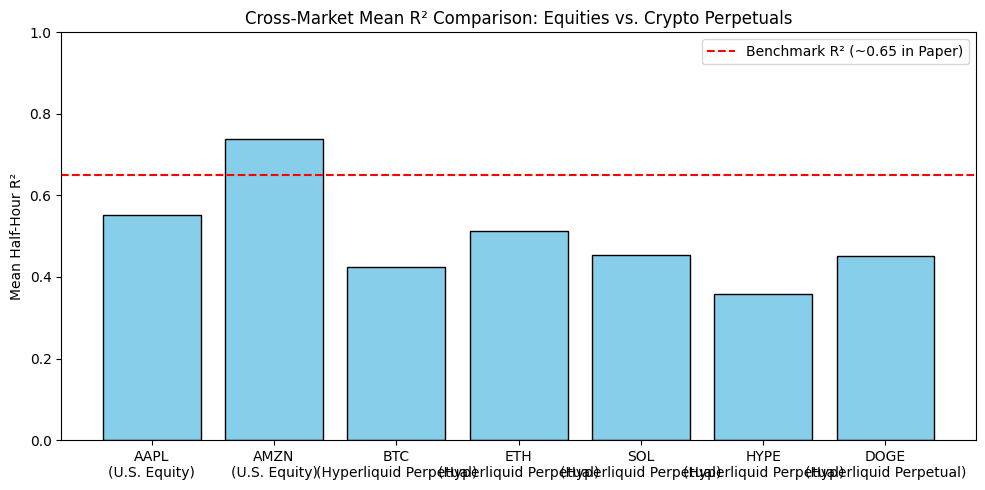

,asset,regressions,mean_r2,median_r2,significant_beta_pct,lambda_hat,market
0,AAPL,13,0.552423,0.582153,92.307692,2.001846,U.S. Equity
1,AMZN,13,0.739302,0.800122,92.307692,2.851847,U.S. Equity
2,BTC,144,0.425151,0.436517,100.000000,-0.600849,Hyperliquid Perpetual
3,ETH,144,0.512717,0.549440,100.000000,0.214707,Hyperliquid Perpetual
4,SOL,144,0.453837,0.477588,100.000000,1.185892,Hyperliquid Perpetual
5,HYPE,144,0.359236,0.368920,97.916667,1.321857,Hyperliquid Perpetual
6,DOGE,144,0.451902,0.490979,100.000000,0.604384,Hyperliquid Perpetual


In [14]:
COMPARISON_FOLDER = RESULTS_DIR / "market_comparison"
COMPARISON_FOLDER.mkdir(parents=True, exist_ok=True)

c_file = RESULTS_DIR / "cross_token_summary.csv"
s_file = STOCK_RESULTS_DIR / "cross_stock_summary.csv"

if c_file.exists() and s_file.exists():
    crypto_df = pd.read_csv(c_file).rename(columns={"token": "asset"})
    crypto_df["market"] = "Hyperliquid Perpetual"
    
    stock_df = pd.read_csv(s_file).rename(columns={"symbol": "asset"})
    stock_df["market"] = "U.S. Equity"
    
    combined = pd.concat([stock_df, crypto_df], ignore_index=True)
    combined.to_csv(COMPARISON_FOLDER / "stock_vs_crypto_summary.csv", index=False)
    
    plt.figure(figsize=(10, 5))
    plt.bar(combined["asset"] + "\n(" + combined["market"] + ")", combined["mean_r2"], color="skyblue", edgecolor="black")
    plt.axhline(0.65, linestyle="--", color="red", label="Benchmark R² (~0.65 in Paper)")
    plt.title("Cross-Market Mean R² Comparison: Equities vs. Crypto Perpetuals")
    plt.ylabel("Mean Half-Hour R²")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.savefig(COMPARISON_FOLDER / "01_mean_r2_comparison.png", dpi=150)
    plt.show()
    
    display(combined)
else:
    print("Run preceding sections to generate cross-market comparisons.")